In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
#Leitura dos dados

# idade de aponsentadoria
dados_idade_aposentadoria = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\dados_idade_aposentadoria.csv")

dados_vida_lampada = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\dados_vida_lampada.csv")

# Altura dos funcionarios
dados_alturas = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\dados_alturas.csv")

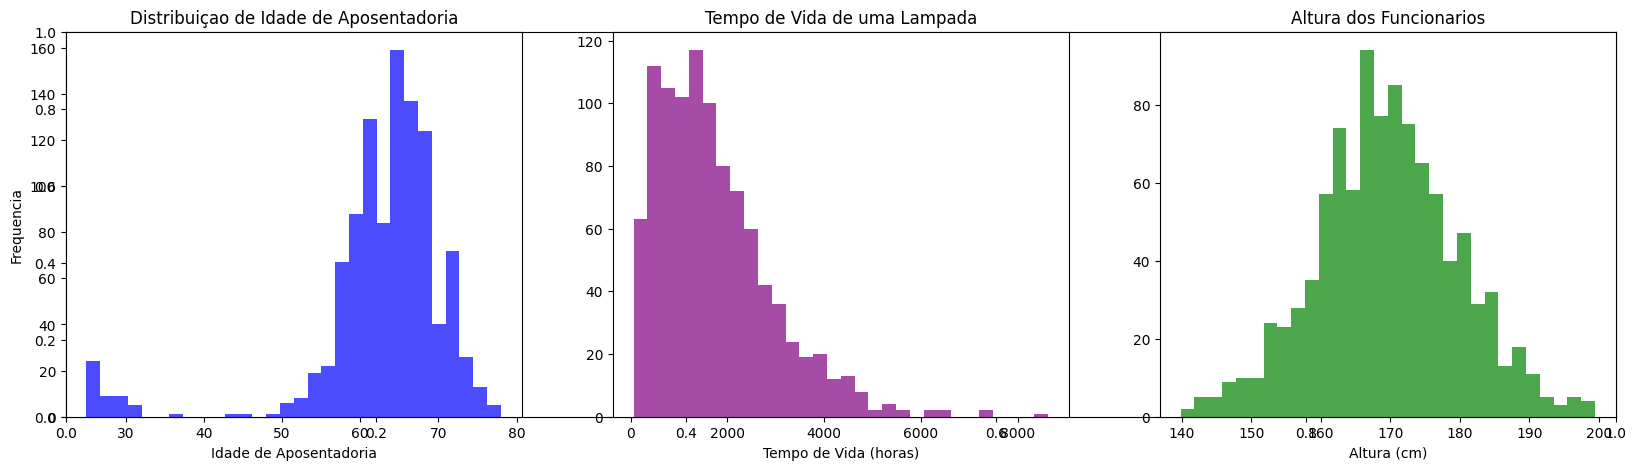

In [86]:
#variaveis de distribuiçoes
plt.subplots(figsize=(20,5))
plt.subplot(131)
plt.title("Distribuiçao de Idade de Aposentadoria")
plt.xlabel('Idade de Aposentadoria')
plt.ylabel('Frequencia')
plt.hist(dados_idade_aposentadoria, bins=30, alpha=0.7, color='blue')


plt.subplot(132)
plt.title("Tempo de Vida de uma Lampada")
plt.xlabel('Tempo de Vida (horas)')
plt.hist(dados_vida_lampada, bins=30, alpha=0.7, color='purple')


plt.subplot(133)
plt.title("Altura dos Funcionarios")
plt.xlabel('Altura (cm)')

plt.hist(dados_alturas, bins=30, alpha=0.7, color='green')

plt.show()
 


# FAZENDO A REAMOSTRAGEM:

In [87]:
# Reamostragens

# tamanho da amostra
n = 100
# quantidade de amostras
qnt = 100000

# função de reamostragem e cálculo de médias
def reamostragem_media(dados, coluna, n, qnt):
    medias = [dados[coluna].sample(n, replace=True).mean() for _ in range(qnt)]
    return medias

In [88]:
dados_idade_aposentadoria.head()

,idade
0,66
1,66
2,60
3,61
4,57


In [89]:
dados_vida_lampada.head()

,duracao
0,2238.462196
1,404.474833
2,358.025869
3,2193.463611
4,1072.377941


In [90]:
dados_alturas.head()

,alturas
0,167.52
1,185.21
2,172.74
3,171.52
4,157.75


In [91]:
#Realizando as reamostragens com a funçao:
medias_idade = reamostragem_media(dados_idade_aposentadoria, 'idade', n, qnt)
medias_duracao = reamostragem_media(dados_vida_lampada, 'duracao', n, qnt)
medias_altura = reamostragem_media(dados_alturas, 'alturas', n, qnt)

# COMPARADANDO AS MEDIAS ORIGINAIS COM AS MEDIAS DAS REAMOSTRAGENS CRIADAS:

In [92]:
print("*****  Médias populacionais *****")

print("idade:", dados_idade_aposentadoria['idade'].mean())
print("duração:", dados_vida_lampada['duracao'].mean())
print("altura:", dados_alturas['alturas'].mean())

*****  Médias populacionais *****
idade: 62.70857142857143
duração: 1731.8036029420002
altura: 169.52022


In [93]:
def Average(lst):
    return sum(lst) / len(lst)

print("*****  Médias pamostrais *****")

print("idade:", Average(medias_idade))
print("duração:", Average(medias_duracao))
print("altura:", Average(medias_altura))

*****  Médias pamostrais *****
idade: 62.71047109999939
duração: 1732.493260245201
altura: 169.51995965699803


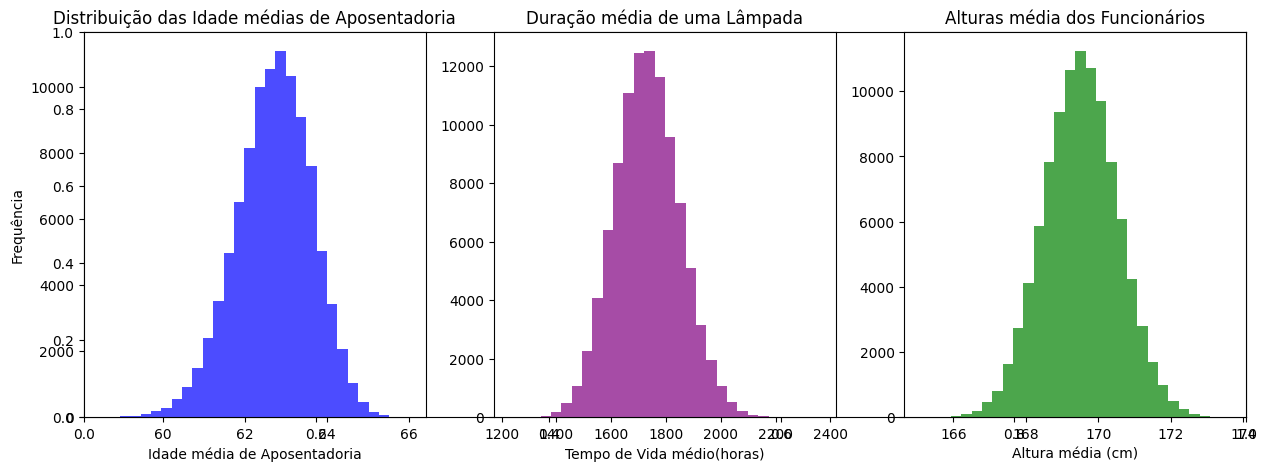

In [94]:
plt.subplots(figsize=(15, 5))
plt.subplot(131)
plt.title('Distribuição das Idade médias de Aposentadoria')
plt.xlabel('Idade média de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(medias_idade, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')

plt.subplot(133)
plt.hist(medias_altura, bins=30, alpha=0.7, color='green')
plt.title('Alturas média dos Funcionários')
plt.xlabel('Altura média (cm)')

plt.show()

In [95]:
# média da nova amostra
media_nova_amostra = 1200

In [96]:
# media original
dados_vida_lampada['duracao'].mean()

np.float64(1731.8036029420002)

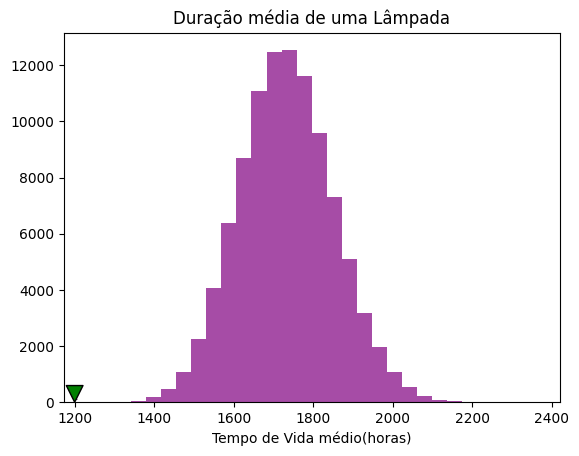

In [97]:
# Quão distante essa média está do comportamento?

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [98]:
# transformando medias_duração em DataFrame
duracao_amostras = pd.DataFrame({'medias_duracao': medias_duracao})

In [99]:
# calculando informações
media_das_medias = duracao_amostras['medias_duracao'].mean()
EP = duracao_amostras['medias_duracao'].std()

print("*****  Medidas amostrais *****")
print("média:", media_das_medias )
print("Erro Padrão:", EP )

*****  Medidas amostrais *****
média: 1732.4932602452088
Erro Padrão: 118.45289111329006


In [100]:
# Quantos erros?
1732 - EP

np.float64(1613.54710888671)

In [101]:
# Quantos erros?
1732 - 3*EP

np.float64(1376.6413266601298)

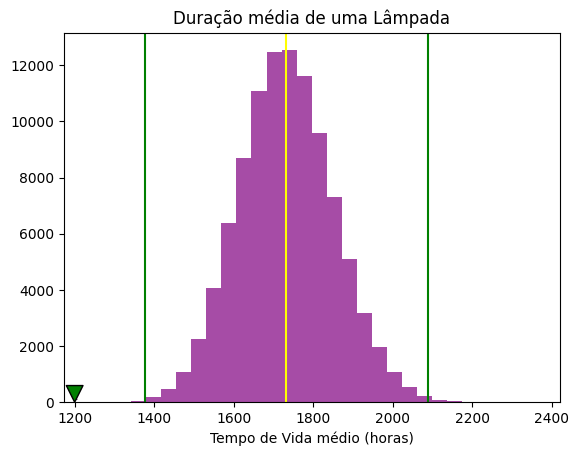

In [102]:
# Visualizando a quantidade de amostras entre 3EP +- da média.

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio (horas)')
plt.axvline(media_das_medias, color = "yellow")
plt.axvline(media_das_medias + 3*EP , color = "green")
plt.axvline(media_das_medias - 3*EP , color = "green")
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [103]:
#quanto está no intervalo de +ou- dois desvio
qnt_obs = duracao_amostras[(duracao_amostras > media_das_medias - 3*EP) &
                          (duracao_amostras < media_das_medias + 3*EP)]

In [104]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()

medias_duracao    0.99738
dtype: float64

In [105]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()*100

medias_duracao    99.738
dtype: float64

In [106]:
# importando o stats
from scipy import stats

In [107]:
# levar em consideração essa amostra
dados_vida_lampada

# nível de confiança definido
confianca = 0.95

In [108]:
#informações para o IC

media = dados_vida_lampada['duracao'].mean()
desvio_padrao_amostral = dados_vida_lampada['duracao'].std()
tamanho_amostra = len(dados_vida_lampada)

In [109]:
intervalo_confianca = stats.norm.interval(confianca)

In [110]:
# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media ,
                                       scale=desvio_padrao_amostral/np.sqrt(tamanho_amostra))

In [111]:
# Visualizando os resultados

print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(1658.3741665835487), np.float64(1805.2330393004518))


# 2) Estabelecer a duração de novas lâmpadas

 2.1 entender se a duração média das lâmpadas de Natal, também fabricadas por esta indústria, é igual a ou diferente de 1.570 horas.

In [112]:
# hipotese nula
hipotese = 1570

In [113]:
# dados amostrais

lampadas_natalinas = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\experimento_lampadas_natalinas.csv")

In [114]:
lampadas_natalinas.head()

,Unnamed: 0,duracao
0,0,1541.121474
1,1,1523.495329
2,2,1521.732707
3,3,1523.280091
4,4,1530.643374


In [118]:
lampadas_natalinas['duracao'].mean()

np.float64(1529.5081310675512)

In [115]:
#informações para a região crítica

confianca = 0.95  # Nível de confiança desejado
desvio_padrao_populacional = 105  #sigma dado pela fabrica
tamanho_amostra = len(lampadas_natalinas['duracao'])

In [119]:
# Calculando o IC

intervalo = stats.norm.interval( confianca,
                                 loc = 1570,
                                 scale = desvio_padrao_populacional/np.sqrt(tamanho_amostra) ) #desvio padrao divido pela raiz quadrada do tamanho da amostra

In [117]:
print("IC (95%)): ", intervalo)

IC (95%)):  (np.float64(1549.4203781623294), np.float64(1590.5796218376706))


In [120]:
#O valor 1529 nao esta incluso dentro intervalo com isto nao tem evidencia que as lampadas natalinas duram 1570 como foi estabelecido na HIPOTESE NULA, pois o valor observado nao esta contido no intervalo. 
#A decisao e reijeitar a hiposese nula.

In [121]:
#Trazer um outro questionamento. 
#Analisando se esta sendo tomado alguma decisão errada? E se, na verdade, as lâmpadas realmente duram isso? 
#E esta sendo afirmando que elas não duram. Para verificar isto esta sendo calculado abaixo o erro em cima da decisão:

In [123]:
#Anteriormente, foi calculado o intervalo de confiança com base nas médias de duração das lâmpadas natalinas observadas. 
#Comparando com esse intervalo de confiança, rejeitamos a hipótese nula.
#Ou seja, concluímos que não podemos afirmar que as lâmpadas duram, em média, 1.570 horas. 
#Mas e se estivéssemos cometendo um erro? E se, na verdade, estivéssemos afirmando que elas não duram e, de fato, elas duram? Esse é o erro associado às nossas hipóteses.

#Precisamos identificar alguns pontos que estabelecemos na nossa análise. 
#Quando fizemos o intervalo de confiança, estabelecemos o critério de confiança de 95%. Sabemos, inclusive, com aquele experimento que fizemos no início deste curso, que temos 95 amostras de 100 representadas nesse intervalo.
#Quando definimos a confiança, também definimos o quanto estamos dispostos a errar.

#Quando falamos sobre 95% de confiança, temos aí 5%. E como nomeamos isso? Chamamos de nível de significância, que é, inclusive, um termo técnico para essa porcentagem. 
#Isso significa que estamos dispostos a errar até 5%, que, inclusive, é a probabilidade de rejeitar H₀, sendo que, na verdade, ela é verdadeira.
#nivel de confiança = 95%  nivel de significancia = 5%

# Descrevendo a intensidade de rejeitar a hipótese - Aplicando o Teste Z:


In [125]:
# importando o teste Z do statsmodels
from statsmodels.stats.weightstats import ztest

In [128]:
# executando o teste z
stats, p_valor = ztest(x1 = lampadas_natalinas['duracao'], value = 1570, alternative = "two-sided") #hipotese alternativa, quando tem apenas uma alterativa de 2 hipoteses = two-side 

In [129]:
# media_amostral
lampadas_natalinas['duracao'].mean()

np.float64(1529.5081310675512)

In [130]:
# exibe os resultados

print(p_valor)

0.0


In [127]:
# verifica a hipótese nula com base no valor-p

if p_valor < 0.05:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Conclusão: Rejeitar a hipótese nula


# 4) Formulando outras hipóteses - Conhecendo o caso 4: nível de serviço (SLA) - Projeto para uma empresa de software


# Aplicando o teste t - Com apenas uma Amostra:

In [1]:
# Tempo de resposta em minutos para 25 solicitações de suporte
tempo_resposta = [28, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 24, 29, 30]

In [4]:
# Média coletada do tempo
np.mean(tempo_resposta)

np.float64(29.96)

In [5]:
# Importando ttest_1samp
from scipy.stats import ttest_1samp

In [6]:
# Realiza o teste t unilateral para uma amostra
stats, p_valor = ttest_1samp(tempo_resposta, 30, alternative = "less")

In [8]:
# Exibe os resultados:
print(p_valor)

0.4585970095667924


# Interpretando o teste T

In [9]:
nivel_significancia = 0.05

if p_valor < nivel_significancia:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

conclusao

'Não rejeita a hipótese nula'

In [10]:
#Conclusão:
#No final, informamos que não há evidências estatísticas para afirmar que o tempo médio do suporte é menor que 30 minutos.

# 5) Caso 5: Vendas vs Anúncio
# Testando em amostras independentes

In [12]:
vendas_com_propaganda = [329.80, 291.70, 338.86, 391.38, 285.95, 285.95, 394.75, 346.05, 271.83, 332.55, 272.19, 272.06, 314.52, 185.20, 196.50, 266.26, 239.23, 318.85, 245.52, 215.26, 387.94, 286.45, 304.05, 214.52, 267.34, 306.66, 230.94, 322.54, 263.96, 282.50, 263.90, 411.14, 299.19, 236.54, 349.35, 226.75, 312.53, 182.42, 220.31, 311.81, 344.31, 310.28, 293.66, 281.93, 211.29, 256.81, 272.36, 363.43, 320.62, 194.22]

In [13]:
vendas_sem_propaganda = [304.44, 261.89, 244.38, 321.70, 346.86, 348.08, 234.65, 266.45, 304.88, 343.53, 256.25, 273.86, 218.62, 213.23, 333.75, 366.37, 280.68, 345.21, 306.70, 246.29, 306.68, 377.28, 282.85, 378.88, 127.82, 334.31, 290.22, 267.06, 290.51, 165.74, 271.82, 306.43, 373.67, 253.90, 236.49, 254.89, 339.92, 304.73, 253.21, 315.80, 292.80, 343.12, 242.88, 265.34, 261.47, 197.19, 302.77, 300.66, 285.31, 270.92]

In [16]:
# Media Com Propagandas:
print(np.mean(vendas_com_propaganda))

# Media Sem Propagandas:
print(np.mean(vendas_sem_propaganda))

286.4832
286.2498


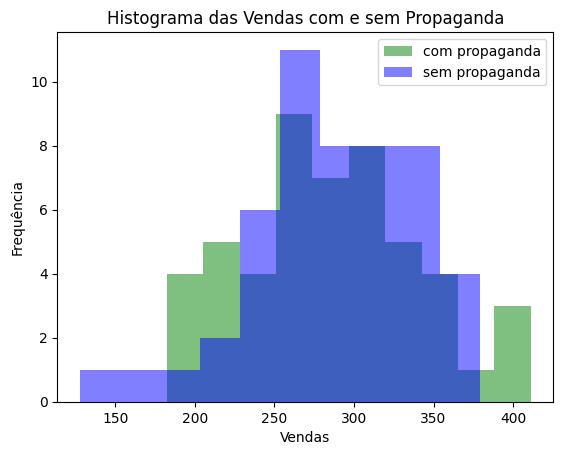

In [19]:
# Criar histogramas
plt.hist(vendas_com_propaganda, color = "green", alpha = 0.5, label = "com propaganda")
plt.hist(vendas_sem_propaganda, color = "blue", alpha = 0.5, label = "sem propaganda")

# Adicionar rótulos e título
plt.xlabel('Vendas')
plt.ylabel('Frequência')
plt.title('Histograma das Vendas com e sem Propaganda')
plt.legend()
plt.show()

Hipóteses desse teste de amostras independentes:

H0: média sem = média com

H1: média sem < média com


In [ ]:
from scipy.stats import ttest_ind

In [28]:
# Aplicacao do teste t de Student para amostras independentes:  
stats, p_valor = ttest_ind (vendas_com_propaganda, vendas_sem_propaganda, alternative = "greater")

In [29]:
# Exibicao dos Resultados:
print(p_valor)

0.49145652153110797


In [30]:
# Interpretacao dos resultados:
alpha = 0.05
if p_valor < alpha:
    print("Rejeitar a hipótese nula: Há evidências de que a propaganda tem um efeito positivo nas vendas.")
else:
    print("Não rejeita hipótese nula: Não há evidências suficientes para afirmar um efeito positivo nas vendas devido à propaganda.")

Não rejeita hipótese nula: Não há evidências suficientes para afirmar um efeito positivo nas vendas devido à propaganda.


# Caso 6: Notas antes e depois - Utilizando amostras pareadas

In [32]:
antes_do_treinamento =[78, 65, 75, 80, 85, 88, 79, 81, 76, 84]
apos_o_treinamento = [85, 70, 75, 87, 90, 92, 84, 82, 76, 91]

In [33]:
# Comparando antes e depois
resultado_subtracao = [b - a for a, b in zip(antes_do_treinamento,apos_o_treinamento)]

In [34]:
resultado_subtracao

[7, 5, 0, 7, 5, 4, 5, 1, 0, 7]

# Diferenciando antes e depois - Aplicando o t test pareado

In [38]:
# importando o teste pareado ttest_rel
from scipy.stats import ttest_rel

In [39]:
# Aplicando o test t pareado: 
stats, p_valor = ttest_rel(apos_o_treinamento, antes_do_treinamento, alternative="greater")

In [37]:
print(p_valor)

0.0006277441617723938


In [40]:
#O valor foi muito baixo, ou seja, rejeitamos a hipótese nula, que é que não houve diferença. 
# Assumimos, então, que há uma diferença após o treinamento. 
# E essa diferença é maior na satisfação dos nossos clientes. Dessa forma, aplicamos um teste para amostras pareadas.